# Task 1 — Data Loading & Exploration

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head(10))
print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

In [156]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Create a copy for EDA
df_original = df.copy()

In [157]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [158]:
attrition_rate = (df['Attrition'].value_counts()['Yes'] / len(df))*100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [159]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))

Numeric: 26
Categorical: 9


# Task 2: Data Cleaning & Preprocessing

In [160]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

In [161]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [162]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [163]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Task 3: Exploratory Data Analysis

In [165]:
dept_attrition = pd.crosstab(
    df_original['Department'],
    df_original['Attrition'],
    normalize='index'
)*100

In [166]:
job_attrition = pd.crosstab(
    df_original['JobRole'],
    df_original['Attrition'],
    normalize='index'
)*100

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

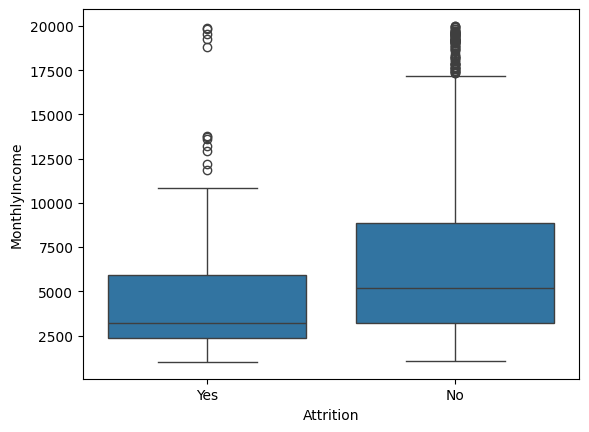

In [167]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_original
)

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

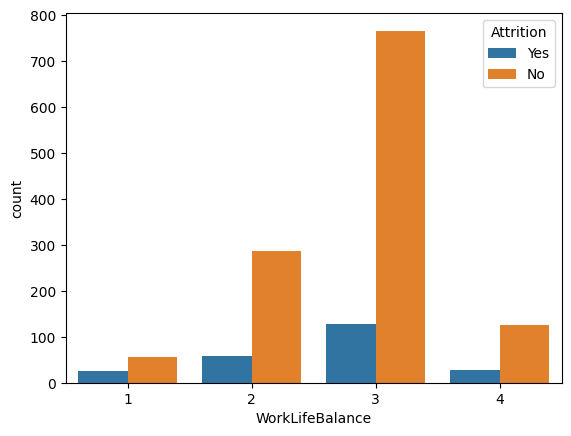

In [168]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df_original
)

<Axes: xlabel='YearsAtCompany', ylabel='Count'>

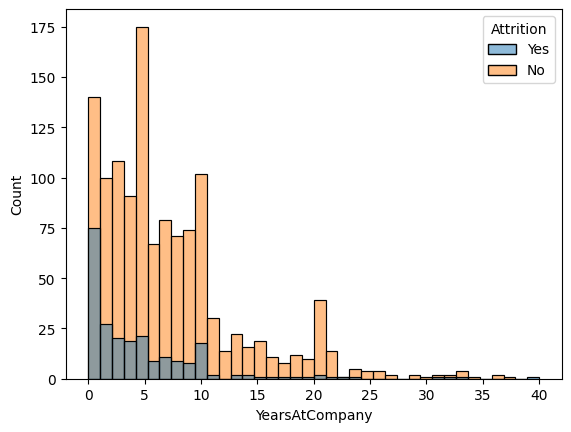

In [169]:
sns.histplot(
    data=df_original,
    x='YearsAtCompany',
    hue='Attrition'
)

# Task 4: Build Models

In [170]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [171]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Random Forest

In [172]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Gradient Boosting

In [173]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

# Task 5: Evaluation

In [174]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)

def evaluate(model):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, prob)

    print(classification_report(y_test,pred))

    print("ROC AUC:",auc)

In [175]:
evaluate(lr)
evaluate(rf)
evaluate(gb)

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC AUC: 0.798604530967353
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294

ROC AUC: 0.7519166164182962
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       

In [176]:
comparison = pd.DataFrame({
    'Model':[],
    'Precision':[],
    'Recall':[],
    'F1':[],
    'ROC_AUC':[]
})

Visualizations

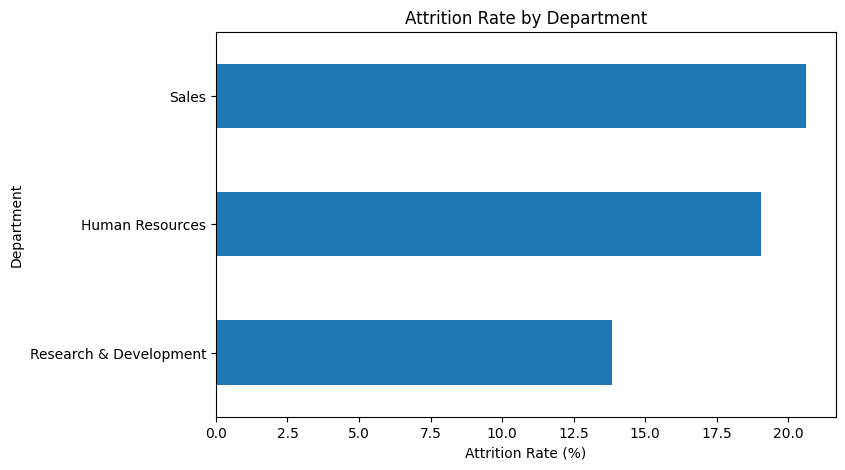

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

dept_attrition = pd.crosstab(
    df_original['Department'],
    df_original['Attrition'],
    normalize='index'
) * 100

dept_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")
plt.show()

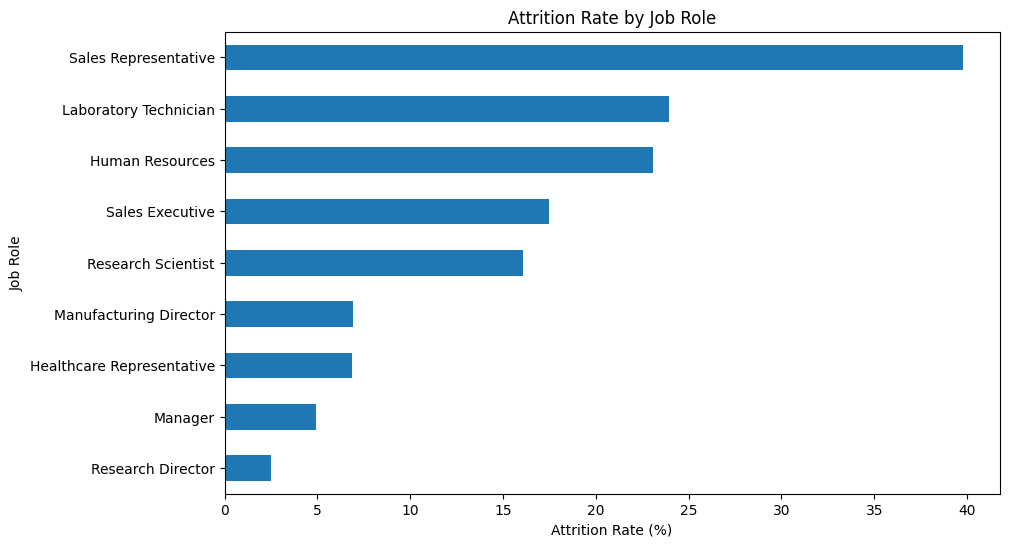

In [178]:
job_attrition = pd.crosstab(
    df_original['JobRole'],
    df_original['Attrition'],
    normalize='index'
) * 100

job_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

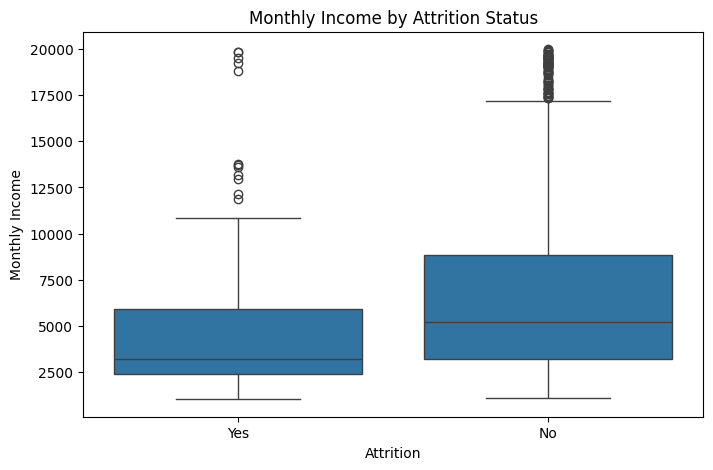

In [179]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_original
)

plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [180]:
pred = rf.predict(X_test)

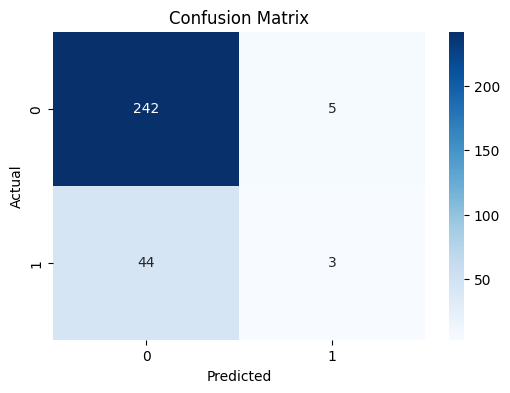

In [181]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

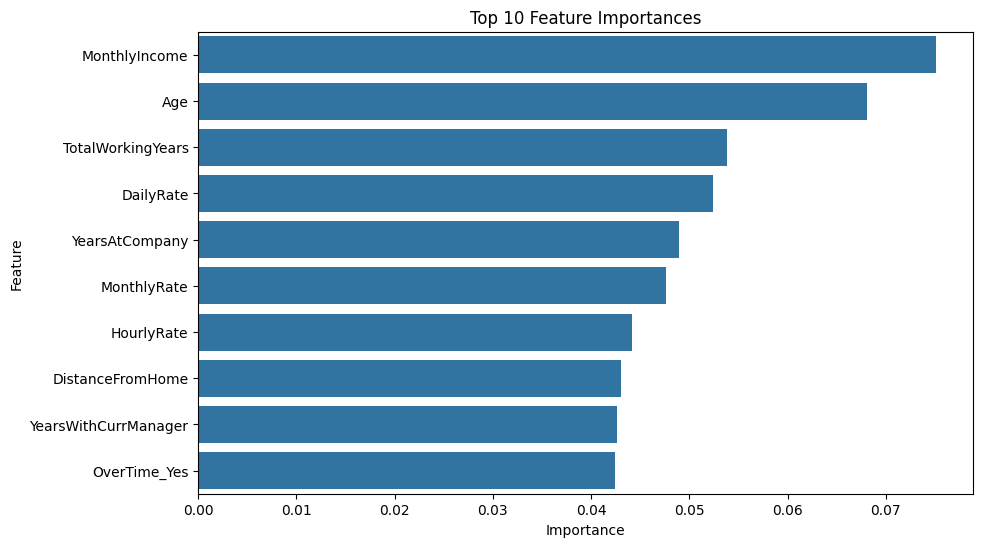

In [182]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Feature Importances")
plt.show()

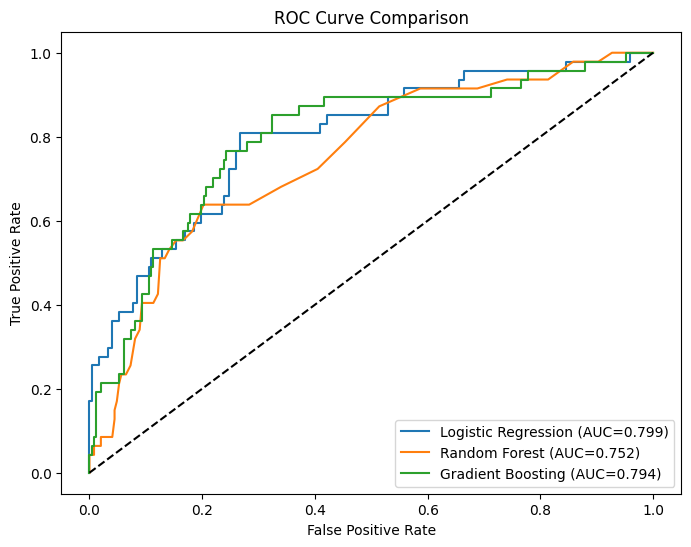

In [183]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()